Econometrics Project

In [1]:
import warnings
from dataclasses import dataclass
from math import floor
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# %% ------------------------------ CONFIG ------------------------------
@dataclass(frozen=True)
class Period:
    name: str
    start: str
    end: str

TICKERS: Dict[str, str] = {
    "Copper": "HG=F",               # Copper futures (COMEX)
    "BCOM": "^BCOM",                # Bloomberg Commodity Index
}

PERIODS: List[Period] = [
    Period("2015–2019", "2015-01-01", "2019-12-31"),
    Period("2020–2024", "2020-01-01", "2024-12-31"),
]

DATE_FMT = mdates.DateFormatter("%Y-%m")
DATE_LOC = mdates.AutoDateLocator(minticks=6, maxticks=12)

In [3]:
# %% ------------------------------ I/O ------------------------------
def download_yahoo_data(
    ticker: str,
    start: str,
    end: str,
    interval: str = "1d",
) -> pd.DataFrame:
    """Download OHLCV from Yahoo Finance (Close indexed by Date)."""
    df = yf.download(ticker, start=start, end=end, interval=interval, auto_adjust=False)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    return df.sort_index()

def fetch_assets(
    tickers: Dict[str, str],
    start: str = "2015-01-01",
    end: str = "2024-12-31",
    interval: str = "1d",
) -> Dict[str, pd.DataFrame]:
    """Batch download into a dict: {asset_name: df}."""
    return {name: download_yahoo_data(tkr, start, end, interval) for name, tkr in tickers.items()}

In [4]:
# %% ------------------------------ TRANSFORMS ------------------------------
def compute_metrics_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return tidy DataFrame with columns:
      Date, Return, LogReturn, SqLogReturn
    LogReturn = log(S_t / S_{t-1})
    """
    out = pd.DataFrame(index=df.index)
    close = df["Close"].astype("float64")
    out["Return"] = close.pct_change()
    out["LogReturn"] = np.log(close / close.shift(1))
    out["SqLogReturn"] = out["LogReturn"] ** 2
    out = out.dropna().reset_index().rename(columns={"index": "Date"})
    return out

def split_by_period(df_metrics: pd.DataFrame, periods: Iterable[Period]) -> Dict[str, pd.DataFrame]:
    """Split a metrics df by named periods: {'2015–2019': df, ...}."""
    out: Dict[str, pd.DataFrame] = {}
    m = df_metrics.copy()
    m["Date"] = pd.to_datetime(m["Date"])
    for p in periods:
        mask = (m["Date"] >= p.start) & (m["Date"] <= p.end)
        out[p.name] = m.loc[mask].reset_index(drop=True)
    return out

In [5]:
# %% ------------------------------ PLOTTING HELPERS ------------------------------
def _format_ax_time(ax):
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(DATE_LOC)
    ax.xaxis.set_major_formatter(DATE_FMT)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

def plot_returns_grid(metrics_by_asset: Dict[str, Dict[str, pd.DataFrame]]):
    """
    Grid of returns (one row per asset, two cols for periods).
    metrics_by_asset: {'Asset': {'2015–2019': df, '2020–2024': df}}
    """
    n_assets = len(metrics_by_asset)
    fig, axes = plt.subplots(n_assets, 2, figsize=(16, 3.5 * n_assets), sharey='row')
    axes = np.atleast_2d(axes)

    for r, (asset, parts) in enumerate(metrics_by_asset.items()):
        # y-lims consistent within asset across its periods
        rets = [parts[p]["Return"].astype(float).to_numpy() for p in parts]
        y_min, y_max = float(np.nanmin([x.min() for x in rets])), float(np.nanmax([x.max() for x in rets]))
        for c, (pname, dfp) in enumerate(parts.items()):
            ax = axes[r, c]
            ax.plot(dfp["Date"], dfp["Return"])
            ax.set_title(f"{asset} Returns ({pname})")
            if c == 0:
                ax.set_ylabel("Returns")
            ax.set_ylim(y_min, y_max)
            _format_ax_time(ax)

    fig.suptitle("Returns Comparison Across Periods", fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

def plot_overlays(metrics_by_asset: Dict[str, Dict[str, pd.DataFrame]], periods: Iterable[Period]):
    """Overlay the two periods for each asset in two stacked panels."""
    fig, axes = plt.subplots(len(metrics_by_asset), 1, figsize=(16, 4.5 * len(metrics_by_asset)), sharex=False)
    axes = np.atleast_1d(axes)

    pnames = [p.name for p in periods]
    for ax, (asset, parts) in zip(axes, metrics_by_asset.items()):
        for pname in pnames:
            dfp = parts[pname]
            ax.plot(dfp["Date"], dfp["Return"], label=pname, alpha=0.9)
        ax.set_title(f"{asset} Returns: Period Overlay")
        ax.set_ylabel("Returns")
        ax.legend()
        _format_ax_time(ax)

    plt.tight_layout()
    plt.show()

In [6]:
# %% ------------------------------ SIMPLE STATS ------------------------------
def period_volatility(dfp: pd.DataFrame) -> float:
    """
    Your original definition: std of squared log-returns.
    (Usually volatility is std of log-returns; keeping your choice.)
    """
    return float(dfp["SqLogReturn"].std())

def summarize_volatilities(metrics_by_asset: Dict[str, Dict[str, pd.DataFrame]]) -> pd.DataFrame:
    rows = [
        {"Asset": asset, "Period": pname, "Volatility(Std[SqLogRet])": period_volatility(dfp)}
        for asset, parts in metrics_by_asset.items()
        for pname, dfp in parts.items()
    ]
    return pd.DataFrame(rows).pivot(index="Asset", columns="Period", values="Volatility(Std[SqLogRet])")

In [7]:
# %% ------------------------------ HAC UTILITIES ------------------------------
def _autobandwidth_newey_west(n: int) -> int:
    """q = floor(4 * (n/100)^(2/9)), at least 1."""
    q = int(floor(4.0 * (n / 100.0) ** (2.0 / 9.0)))
    return max(q, 1)

def long_run_variance_newey_west(x: np.ndarray, q: int | None = None) -> float:
    """
    Newey–West LRV for (mean-zero) series x with Bartlett weights.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.shape[0]
    if n < 3:
        return np.nan
    if q is None:
        q = _autobandwidth_newey_west(n)
    xc = x - x.mean()
    gamma0 = np.dot(xc, xc) / n
    lrv = gamma0 + sum(
        2.0 * (1.0 - h / (q + 1.0)) * (np.dot(xc[h:], xc[:-h]) / n)
        for h in range(1, q + 1)
    )
    return float(lrv)

def hac_two_sample_mean_test(x: np.ndarray, y: np.ndarray, qx: int | None = None, qy: int | None = None,
                             alternative: str = "two-sided") -> dict:
    """
    HAC-robust two-sample test for equality of means of correlated series.
    """
    x = np.asarray(x, dtype=float); x = x[~np.isnan(x)]
    y = np.asarray(y, dtype=float); y = y[~np.isnan(y)]
    n1, n2 = len(x), len(y)
    if n1 < 3 or n2 < 3:
        return {"stat": np.nan, "pvalue": np.nan, "se": np.nan, "n1": n1, "n2": n2}
    qx = _autobandwidth_newey_west(n1) if qx is None else qx
    qy = _autobandwidth_newey_west(n2) if qy is None else qy
    lrv_x = long_run_variance_newey_west(x, q=qx)
    lrv_y = long_run_variance_newey_west(y, q=qy)
    se = np.sqrt(lrv_x / n1 + lrv_y / n2)
    diff = x.mean() - y.mean()
    z = diff / se if se > 0 else np.nan
    pval = (
        2.0 * (1.0 - norm.cdf(abs(z))) if alternative == "two-sided"
        else (1.0 - norm.cdf(z) if alternative == "larger" else norm.cdf(z))
    )
    return {
        "mean_x": x.mean(), "mean_y": y.mean(),
        "diff": diff, "se": se, "stat": z, "pvalue": pval,
        "lags_x": qx, "lags_y": qy, "n1": n1, "n2": n2
    }

def pretty_test(name: str, res: dict) -> dict:
    return {
        "Test": name, "n1": res.get("n1"), "n2": res.get("n2"),
        "mean_x": res.get("mean_x"), "mean_y": res.get("mean_y"),
        "diff": res.get("diff"), "HAC_SE": res.get("se"),
        "z_stat": res.get("stat"), "p_value": res.get("pvalue"),
        "lags_x": res.get("lags_x"), "lags_y": res.get("lags_y"),
    }

In [8]:
# %% ------------------------------ DIAGNOSTICS ------------------------------
def adf_test(x: np.ndarray) -> Tuple[float, float]:
    # H0: unit root (non-stationary). Prefer to REJECT H0.
    res = adfuller(x, autolag="AIC")
    return res[0], res[1]

def kpss_test(x: np.ndarray, regression: str = "c") -> Tuple[float, float]:
    # H0: stationary (level if 'c', trend if 'ct'). Prefer to NOT reject H0.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, pval, *_ = kpss(x, regression=regression, nlags="auto")
    return stat, pval

def lb_test(x: np.ndarray, lags: Iterable[int] = (5, 10, 20)) -> Dict[int, float]:
    return {L: float(acorr_ljungbox(x, lags=[L], return_df=True)["lb_pvalue"].iloc[0]) for L in lags}

def rolling_cv(x: np.ndarray, window: int = 126) -> float:
    s = pd.Series(x).dropna()
    if len(s) < window * 2:
        return np.nan
    rv = s.rolling(window).var()
    return float(rv.std() / rv.mean())

def mean_zero_and_variance_checks(r: np.ndarray, eps: float = 1e-14) -> Tuple[float, float, float, float, bool, bool]:
    r = pd.Series(r).dropna().values
    n = len(r)
    if n < 3:
        return np.nan, np.nan, np.nan, np.nan, True, True
    mean_r = float(np.mean(r))
    var_r = float(np.var(r, ddof=1))
    se_mean = np.sqrt(var_r / n) if var_r > 0 else np.nan
    z_mean = mean_r / se_mean if (np.isfinite(se_mean) and se_mean > 0) else np.nan
    p_mean = 2 * (1 - norm.cdf(abs(z_mean))) if np.isfinite(z_mean) else np.nan
    zero_var_returns = bool(var_r <= eps)

    sq = r**2
    var_sq = float(np.var(sq, ddof=1))
    zero_var_sq = bool(var_sq <= eps)
    return mean_r, var_r, float(z_mean), float(p_mean), zero_var_returns, zero_var_sq

def check_assumptions(name: str, ret_series: np.ndarray, sq_series: np.ndarray) -> dict:
    x = pd.Series(sq_series).dropna().values
    r = pd.Series(ret_series).dropna().values
    n = len(x)
    out = {"series": name, "n": n}

    mean_r, var_r, z_mean, p_mean, zero_var_r, zero_var_sq = mean_zero_and_variance_checks(r)
    out.update({
        "Mean_LogRet": mean_r, "Var_LogRet": var_r,
        "z_mean0": z_mean, "p_mean0": p_mean,
        "ZeroVar_Returns": zero_var_r, "ZeroVar_SqReturns": zero_var_sq
    })

    if n >= 10 and not zero_var_sq:
        adf_stat, adf_p = adf_test(x)
        kpss_stat, kpss_p = kpss_test(x, regression="c")
        lb_p = lb_test(x, lags=(5, 10, 20)) if n >= 20 else {5: np.nan, 10: np.nan, 20: np.nan}
        lrv = long_run_variance_newey_west(x)
    else:
        adf_stat = adf_p = kpss_stat = kpss_p = lrv = np.nan
        lb_p = {5: np.nan, 10: np.nan, 20: np.nan}

    out.update({
        "ADF_stat": adf_stat, "ADF_p": adf_p,
        "KPSS_stat": kpss_stat, "KPSS_p": kpss_p,
        "LB_p_lag5": lb_p[5], "LB_p_lag10": lb_p[10], "LB_p_lag20": lb_p[20],
        "LRV_NW": lrv,
        "RollVar_CV_126": rolling_cv(x, window=126) if n >= 252 else np.nan,
    })
    return out

def safe_hac(x: np.ndarray, y: np.ndarray, label: str) -> dict:
    cond_bad = (
        len(x) < 3 or len(y) < 3 or
        np.var(x, ddof=1) <= 1e-14 or np.var(y, ddof=1) <= 1e-14
    )
    if cond_bad:
        return pretty_test(label, {
            "n1": len(x), "n2": len(y),
            "mean_x": float(np.mean(x)) if len(x) else np.nan,
            "mean_y": float(np.mean(y)) if len(y) else np.nan,
            "diff": (float(np.mean(x)) - float(np.mean(y))) if len(x) and len(y) else np.nan,
            "se": np.nan, "stat": np.nan, "pvalue": np.nan,
            "lags_x": np.nan, "lags_y": np.nan
        })
    return pretty_test(label, hac_two_sample_mean_test(x, y))


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


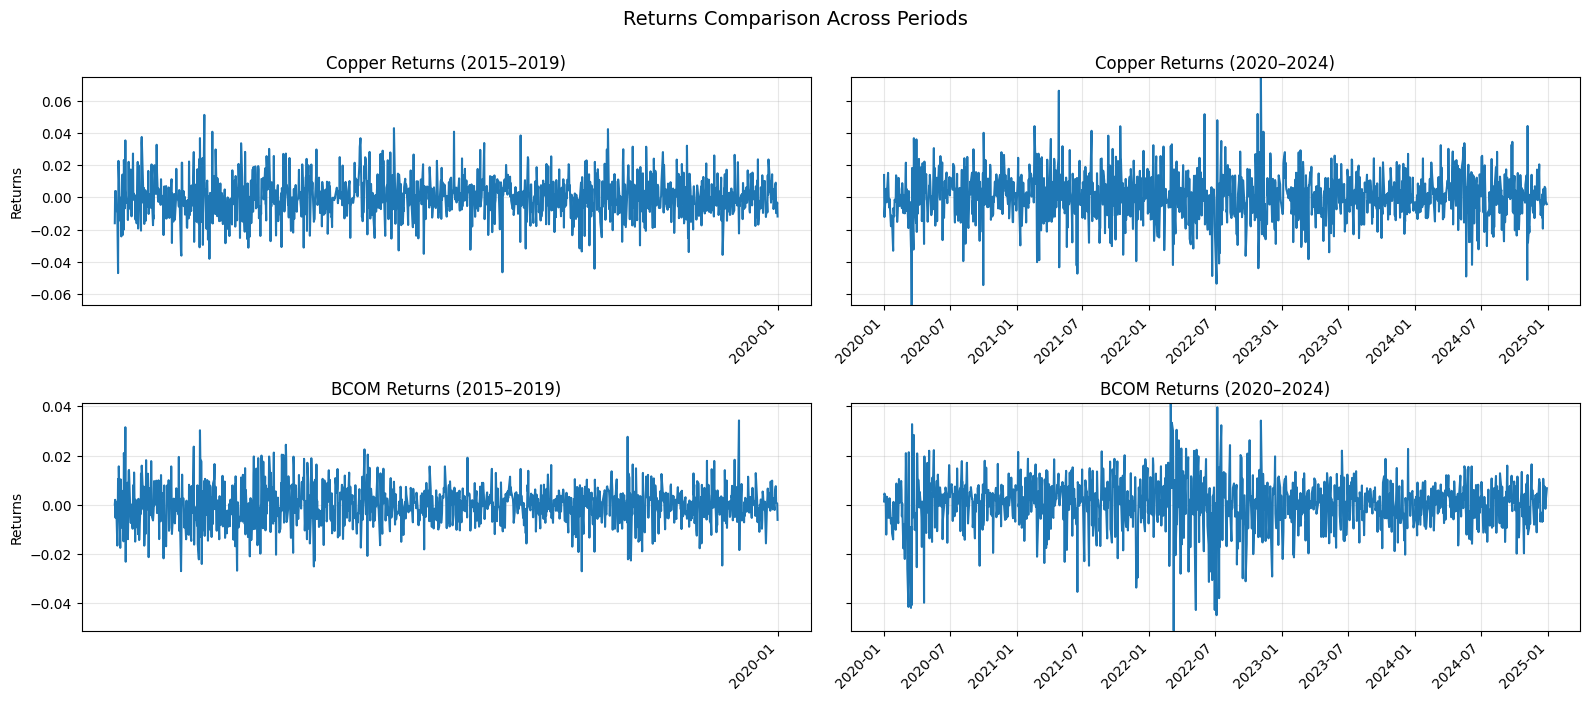

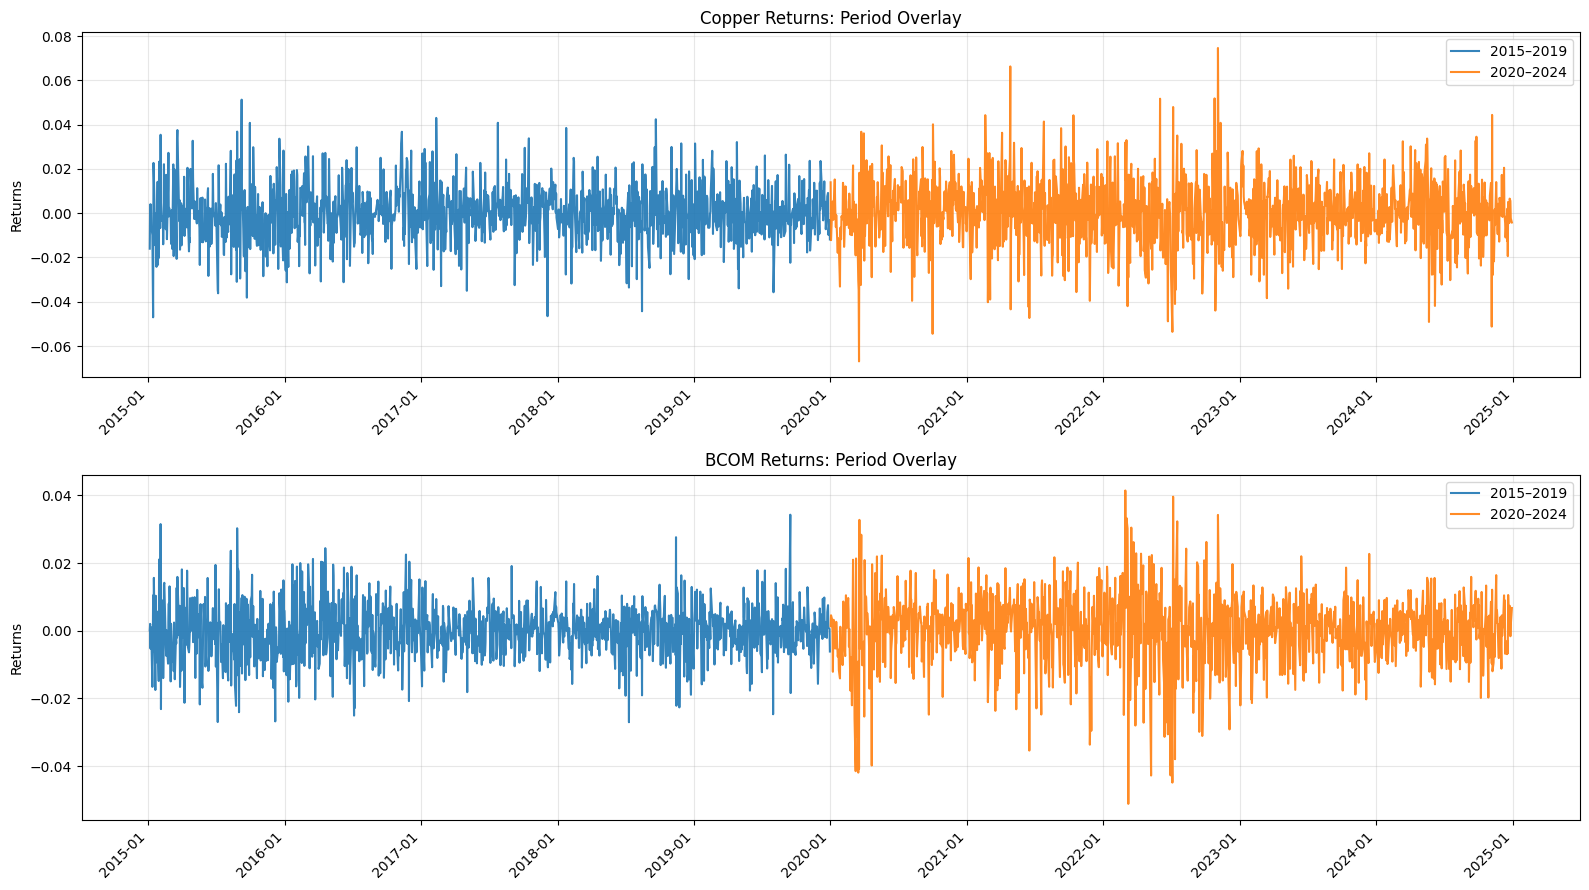


Volatility (Std of SqLogReturn):
 Period  2015–2019  2020–2024
Asset                       
BCOM     0.000112   0.000229
Copper   0.000279   0.000429 

=== Assumption checks for HAC test (squared log-returns) ===
             series     n  Mean_LogRet  Var_LogRet    z_mean0  p_mean0  \
0  Copper 2015–2019  1254 -1.26009e-05 0.000158128 -0.0354851 0.971693   
1  Copper 2020–2024  1258  0.000294222 0.000230167    0.68785 0.491547   
2    BCOM 2015–2019  1257 -0.000198849 6.37175e-05  -0.883207 0.377125   
3    BCOM 2020–2024  1257  0.000159678 0.000106862   0.547649 0.583933   

   ADF_stat       ADF_p  KPSS_stat   KPSS_p   LB_p_lag5  LB_p_lag10  \
0  -32.4478           0    1.21479     0.01   0.0360114  0.00170912   
1  -10.6351 5.09687e-19   0.312085      0.1 7.95057e-11 1.27752e-11   
2  -10.8512 1.52682e-19    2.08254     0.01 3.76061e-15 1.33424e-17   
3  -7.71135  1.2614e-11   0.660262 0.017158 3.86926e-51 1.20264e-78   

   LB_p_lag20      LRV_NW  RollVar_CV_126  ZeroVar_Returns 

In [9]:
# %% ------------------------------ PIPELINE ------------------------------
# 1) Download once
assets_raw = fetch_assets(TICKERS, start="2015-01-01", end="2024-12-31")

# 2) Compute metrics per asset
metrics = {asset: compute_metrics_df(df) for asset, df in assets_raw.items()}

# 3) Split into named periods
metrics_by_asset = {asset: split_by_period(mdf, PERIODS) for asset, mdf in metrics.items()}

# 4) Plots (grid per period + overlay)
plot_returns_grid(metrics_by_asset)
plot_overlays(metrics_by_asset, PERIODS)

# 5) Volatility table (your original definition)
vol_table = summarize_volatilities(metrics_by_asset)
print("\nVolatility (Std of SqLogReturn):\n", vol_table, "\n")

# 6) Assumptions diagnostics (one row per asset×period)
diag_rows = [
    check_assumptions(f"{asset} {pname}",
                      ret_series=parts[pname]["LogReturn"].to_numpy(),
                      sq_series=parts[pname]["SqLogReturn"].to_numpy())
    for asset, parts in metrics_by_asset.items()
    for pname in parts.keys()
]
assumption_df = pd.DataFrame(diag_rows)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
print("=== Assumption checks for HAC test (squared log-returns) ===")
print(assumption_df[
    ["series","n",
     "Mean_LogRet","Var_LogRet","z_mean0","p_mean0",
     "ADF_stat","ADF_p","KPSS_stat","KPSS_p",
     "LB_p_lag5","LB_p_lag10","LB_p_lag20",
     "LRV_NW","RollVar_CV_126",
     "ZeroVar_Returns","ZeroVar_SqReturns"]
])

# 7) HAC/Newey–West robust comparisons
def series(metrics_by_asset: Dict[str, Dict[str, pd.DataFrame]], asset: str, period: str) -> np.ndarray:
    return metrics_by_asset[asset][period]["SqLogReturn"].to_numpy()

res_rows = []
# TIME effects per asset
for asset in metrics_by_asset:
    res_rows.append(safe_hac(series(metrics_by_asset, asset, "2020–2024"),
                             series(metrics_by_asset, asset, "2015–2019"),
                             f"TIME {asset}: mean(post) - mean(pre)"))

# CROSS-asset within each period
for pname in [p.name for p in PERIODS]:
    a, b = list(metrics_by_asset.keys())
    res_rows.append(safe_hac(series(metrics_by_asset, a, pname),
                             series(metrics_by_asset, b, pname),
                             f"CROSS {pname}: mean({a}) - mean({b})"))

summary_df = pd.DataFrame(res_rows)[
    ["Test","n1","n2","mean_x","mean_y","diff","HAC_SE","z_stat","p_value","lags_x","lags_y"]
]
print("\n=== HAC/Newey–West robust tests on mean volatility (squared log-returns) ===")
print(summary_df)


REMARK FOR THE PREVIOUS PART: when we do the variance test between the two time series pre and post covid, we can say that the data at the first date of post is uncorrelated with the data at the last date of the pre covid because in the acf test the legday is small enough